**Cell 1: Import Library dan Persiapan Data**
- Penjelasan untuk dosen: Tahap ini memuat data mentah log sentuhan (TouchLog) dari aplikasi MELE untuk satu partisipan (P-001) dan menggabungkannya ke dalam satu DataFrame agar mudah dianalisis.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

# 1. Load Data
touch_mindful = pd.read_csv('data/P-001_OLD/TouchLog_P-001_Mindful.csv')
touch_mindless = pd.read_csv('data/P-001_OLD/TouchLog_P-001_Mindless.csv')

# 2. Beri Label State
touch_mindful['State'] = 'Mindful'
touch_mindless['State'] = 'Mindless'

# 3. Filter khusus untuk event SCROLL DAN hanya di aplikasi TikTok
scroll_mindful = touch_mindful[
    (touch_mindful['Event_Type'] == 'SCROLL') &
    (touch_mindful['PackageName'] == 'com.ss.android.ugc.trill')
].copy()

scroll_mindless = touch_mindless[
    (touch_mindless['Event_Type'] == 'SCROLL') &
    (touch_mindless['PackageName'] == 'com.ss.android.ugc.trill')
].copy()

print(f"Total Baris Scroll Mindful (TikTok Only): {len(scroll_mindful)}")
print(f"Total Baris Scroll Mindless (TikTok Only): {len(scroll_mindless)}")

Total Baris Scroll Mindful (TikTok Only): 475
Total Baris Scroll Mindless (TikTok Only): 412


**Cell 2: Feature Engineering (Mengekstrak Argumen Psikologis)**
- Penjelasan untuk dosen: Di sini kita menerjemahkan variabel temporal dan kinetik dari jurnal referensi menjadi metrik yang bisa dihitung. Kita menghitung Interswipe Duration (jeda waktu antar scroll) dan Velocity Y (kecepatan absolut pergerakan piksel).

In [14]:
def extract_features(df):
    # Sortir berdasarkan waktu untuk memastikan urutan benar
    df = df.sort_values('Timestamp')

    # 1. Interswipe Duration (Variabel Temporal)
    # Dihitung dari selisih waktu baris saat ini dengan baris sebelumnya (dalam milidetik)
    df['TimeDiff_ms'] = df['Timestamp'].diff()

    # Hindari nilai 0 atau negatif jika ada error sensor
    df = df[df['TimeDiff_ms'] > 0]

    # 2. Velocity Y (Variabel Kinetik)
    # Rumus: |Delta Y| / Delta T
    df['VelocityY'] = (df['ScrollDeltaY'].abs() / df['TimeDiff_ms']) * 1000 # dikonversi ke satuan piksel/detik

    return df

# Aplikasikan ke data
scroll_mindful = extract_features(scroll_mindful)
scroll_mindless = extract_features(scroll_mindless)

# Gabungkan untuk visualisasi perbandingan
df_combined = pd.concat([scroll_mindful, scroll_mindless])

**Cell 3: Pembuktian 1 - Variabel Spasial & Perilaku "Infinite Void"**
- Penjelasan untuk dosen: Menunjukkan bukti bahwa dalam sesi mindless, pengguna secara tidak sadar melewati ribuan piksel (rapidly flicking) karena dorongan dopamin dari fitur infinite scroll, berbeda jauh dengan sesi mindful yang fokus pada konten.

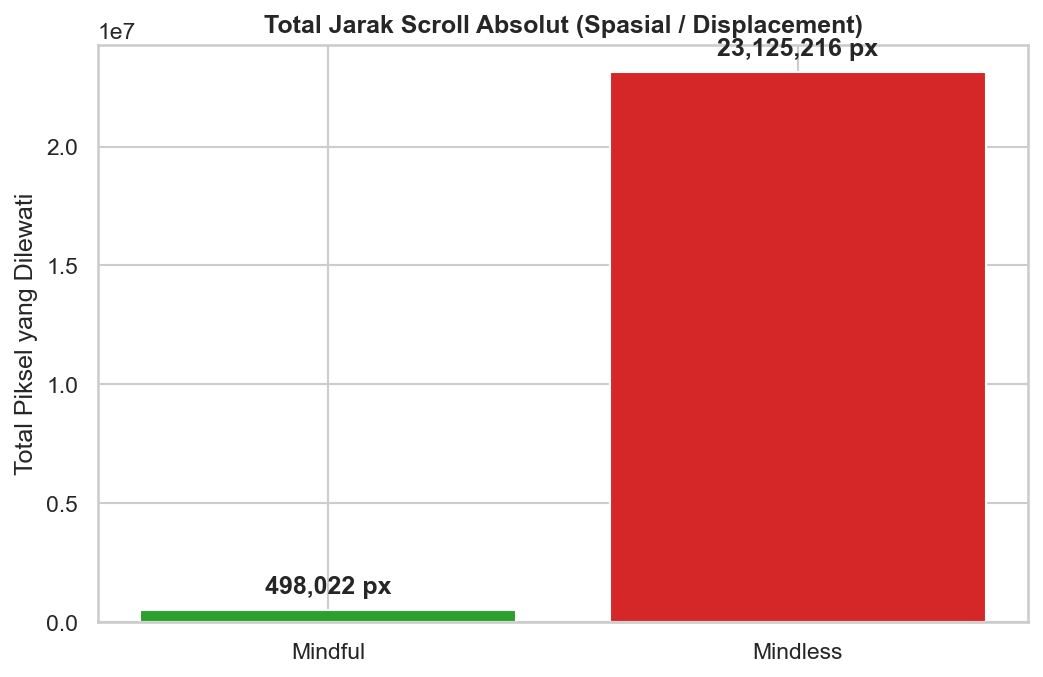


KESIMPULAN: Pada fase Mindless, partisipan melakukan scrolling 46.4x lebih jauh dibandingkan fase Mindful.


In [15]:
# Menghitung total perpindahan layar
total_dist_mindful = scroll_mindful['ScrollDeltaY'].abs().sum()
total_dist_mindless = scroll_mindless['ScrollDeltaY'].abs().sum()

# Visualisasi Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Mindful', 'Mindless'],
              [total_dist_mindful, total_dist_mindless],
              color=['#2ca02c', '#d62728'])

ax.set_title('Total Jarak Scroll Absolut (Spasial / Displacement)', fontweight='bold')
ax.set_ylabel('Total Piksel yang Dilewati')

# Tambahkan label angka di atas bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 500000,
            f"{int(yval):,} px", ha='center', va='bottom', fontweight='bold')

plt.show()

# Print rasio untuk argumen kuat
ratio = total_dist_mindless / total_dist_mindful
print(f"\nKESIMPULAN: Pada fase Mindless, partisipan melakukan scrolling {ratio:.1f}x lebih jauh dibandingkan fase Mindful.")

**Cell 4: Pembuktian 2 - Variabel Temporal & Kinetik (Violin Plot)**
- Penjelasan untuk dosen: Plot ini menggabungkan Boxplot dan kurva kepadatan. Ini akan membuktikan bahwa pada fase Mindless, jeda baca (Interswipe) sangat singkat dan kecepatannya (Velocity) meledak tinggi secara konsisten.

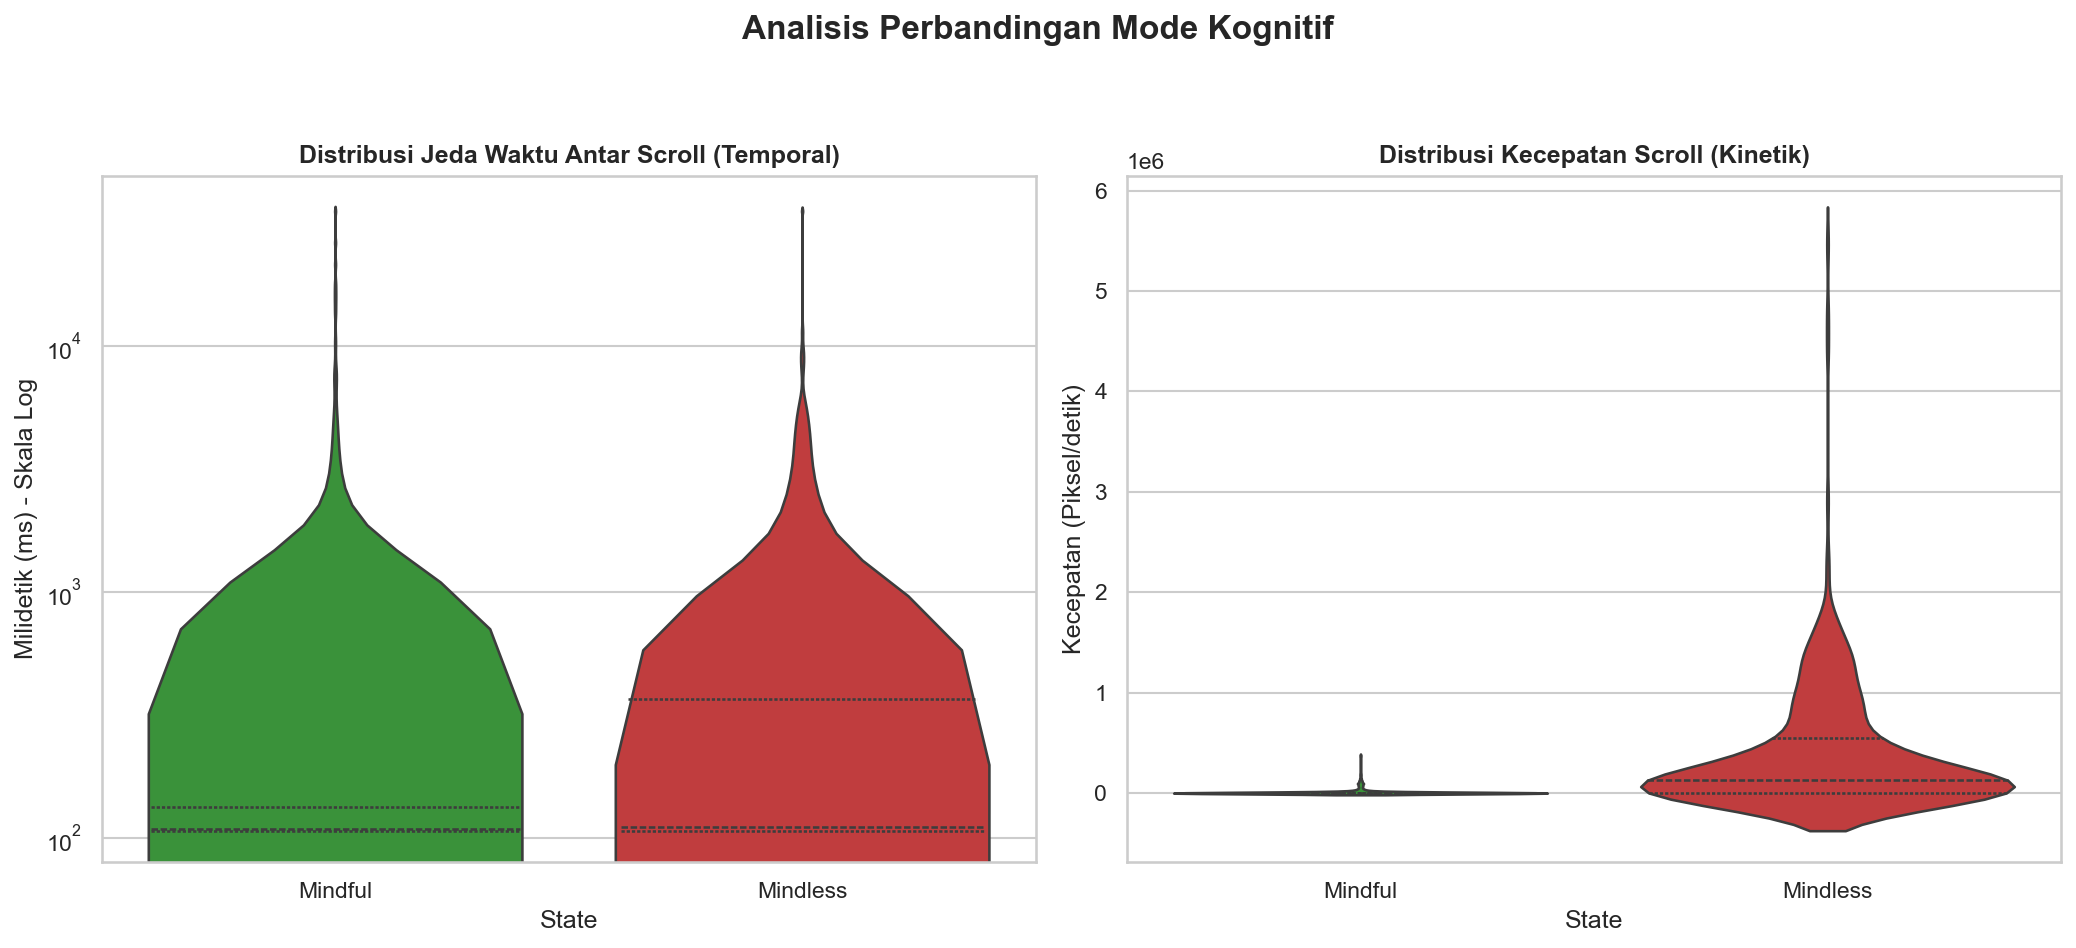

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Interswipe Duration (Jeda Waktu)
# PERBAIKAN: Menggunakan skala logaritmik (log scale)
sns.violinplot(data=df_combined, x='State', y='TimeDiff_ms',
               hue='State', legend=False,
               palette=['#2ca02c', '#d62728'], inner="quartile", ax=axes[0])
axes[0].set_title('Distribusi Jeda Waktu Antar Scroll (Temporal)', fontweight='bold')
axes[0].set_ylabel('Milidetik (ms) - Skala Log')
axes[0].set_yscale('log') # Menampilkan seluruh rentang waktu dengan proporsional

# Plot 2: Velocity Y (Kecepatan)
sns.violinplot(data=df_combined, x='State', y='VelocityY',
               hue='State', legend=False,
               palette=['#2ca02c', '#d62728'], inner="quartile", ax=axes[1])
axes[1].set_title('Distribusi Kecepatan Scroll (Kinetik)', fontweight='bold')
axes[1].set_ylabel('Kecepatan (Piksel/detik)')

plt.suptitle('Analisis Perbandingan Mode Kognitif', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Cell 5: Pembuktian 3 - Rangkuman Statistik (Membuktikan "Low Variance")**
- Penjelasan untuk dosen: Mencetak tabel komparasi matematis agar dosen melihat bahwa data ini sangat layak untuk dilatih ke dalam model Machine Learning.

In [17]:
# Buat tabel summary statistik
summary = df_combined.groupby('State').agg(
    Avg_Velocity_px_s=('VelocityY', 'mean'),
    Median_Velocity_px_s=('VelocityY', 'median'),
    Max_Velocity_px_s=('VelocityY', 'max'),
    Avg_Interswipe_ms=('TimeDiff_ms', 'mean')
).round(2)

print("=== RINGKASAN STATISTIK FITUR BEHAVIORAL ===")
print(summary.T)

=== RINGKASAN STATISTIK FITUR BEHAVIORAL ===
State                   Mindful    Mindless
Avg_Velocity_px_s       7392.70   390670.33
Median_Velocity_px_s       0.00   126778.36
Max_Velocity_px_s     372272.73  5463916.67
Avg_Interswipe_ms        684.43      766.76
